<a href="https://colab.research.google.com/github/Azaidi317/LLM-Finetuning-Projects/blob/main/VMAF_Abdullah.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# VMAF for Autonomous Driving - Google Colab Optimized
# This version is specifically designed to work seamlessly with Google Colab

# Output a message to verify it's running in Colab
try:
    import google.colab
    print("✓ Running in Google Colab environment")
except ImportError:
    print("⚠️ Warning: This notebook is designed for Google Colab but appears to be running elsewhere.")

# Step 1: Install necessary dependencies
print("Installing dependencies...")
!apt-get update -qq > /dev/null
!apt-get install -y ffmpeg > /dev/null

# Install Python packages
!pip install -q numpy opencv-python scikit-learn matplotlib pandas seaborn ffmpeg-python

# Step 2: Clone the Netflix VMAF repository to get models and tools
print("Setting up VMAF...")
!git clone --depth 1 https://github.com/Netflix/vmaf.git 2> /dev/null
!cd vmaf && pip install -q -e .

# Step 3: Set up directories
!mkdir -p uploaded_images reference_images degraded_images

# Step 4: Import required libraries
print("Loading libraries...")
import cv2
import numpy as np
import os
import subprocess
import json
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
from google.colab import files
import shutil
import time
from IPython.display import display, HTML, clear_output

# Display a stylish header
display(HTML("""
<style>
.header {
    background: linear-gradient(to right, #4568dc, #b06ab3);
    color: white;
    padding: 15px;
    border-radius: 10px;
    text-align: center;
    margin-bottom: 20px;
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
}
.subheader {
    font-size: 14px;
    margin-top: 5px;
    opacity: 0.9;
}
</style>
<div class="header">
    <h2 style="margin:0;">VMAF for Autonomous Driving</h2>
    <div class="subheader">Evaluate image quality for self-driving perception systems</div>
</div>
"""))

# Function to create degraded versions of images
def create_degraded_versions(image_path, output_dir):
    """Create degraded versions of an image for VMAF testing"""
    img = cv2.imread(image_path)
    if img is None:
        print(f"Could not read image: {image_path}")
        return None, []

    filename = os.path.basename(image_path)
    name, ext = os.path.splitext(filename)

    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)

    # Progress feedback
    print("Creating degraded versions...", end="")

    # 1. Blur the image (simulates motion blur or focus issues)
    blurred = cv2.GaussianBlur(img, (15, 15), 0)
    blurred_path = os.path.join(output_dir, f"{name}_blurred{ext}")
    cv2.imwrite(blurred_path, blurred)
    print(".", end="", flush=True)

    # 2. Add noise (simulates sensor noise in low light)
    noise = np.zeros(img.shape, np.uint8)
    cv2.randn(noise, 0, 50)
    noisy = cv2.add(img, noise)
    noisy_path = os.path.join(output_dir, f"{name}_noisy{ext}")
    cv2.imwrite(noisy_path, noisy)
    print(".", end="", flush=True)

    # 3. Reduce resolution (simulates lower resolution cameras)
    h, w = img.shape[:2]
    low_res = cv2.resize(img, (w//4, h//4))
    low_res = cv2.resize(low_res, (w, h))
    lowres_path = os.path.join(output_dir, f"{name}_lowres{ext}")
    cv2.imwrite(lowres_path, low_res)
    print(".", end="", flush=True)

    # 4. Reduce contrast (simulates poor lighting conditions)
    low_contrast = cv2.convertScaleAbs(img, alpha=0.5, beta=30)
    contrast_path = os.path.join(output_dir, f"{name}_lowcontrast{ext}")
    cv2.imwrite(contrast_path, low_contrast)
    print(".", end="", flush=True)

    # 5. Heavy compression (simulates transmission artifacts)
    encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), 10]
    _, compressed = cv2.imencode('.jpg', img, encode_param)
    compressed_img = cv2.imdecode(compressed, 1)
    compressed_path = os.path.join(output_dir, f"{name}_compressed{ext}")
    cv2.imwrite(compressed_path, compressed_img)
    print(". Done!")

    return img, [
        (blurred, blurred_path, "Blur"),
        (noisy, noisy_path, "Noise"),
        (low_res, lowres_path, "Low Resolution"),
        (low_contrast, contrast_path, "Low Contrast"),
        (compressed_img, compressed_path, "Compression")
    ]

class VMAF_AV_Evaluator:
    """VMAF evaluator optimized for autonomous vehicle applications"""

    def __init__(self, vmaf_model=None):
        """
        Initialize the VMAF evaluator

        Args:
            vmaf_model: Path to VMAF model file (default: use standard model)
        """
        # Find VMAF model if not specified
        self.vmaf_model = vmaf_model or "vmaf/model/vmaf_v0.6.1.json"

        # Check if model exists and find alternatives if needed
        if not os.path.exists(self.vmaf_model):
            print(f"⚠️ VMAF model not found at {self.vmaf_model}")
            print("Searching for alternative models...")

            # Try to find a model in the vmaf folder
            models = [
                "vmaf/model/vmaf_v0.6.1.json",
                "vmaf/model/vmaf_4k_v0.6.1.json",
                "vmaf/model/vmaf_v0.6.1neg.json",
                # Add more potential model paths
                "vmaf/model/vmaf_v0.6.1.pkl",
                "vmaf/model/vmaf_4k_v0.6.1.pkl"
            ]

            for model in models:
                if os.path.exists(model):
                    self.vmaf_model = model
                    print(f"✓ Found model: {model}")
                    break
        else:
            print(f"✓ Using VMAF model: {os.path.basename(self.vmaf_model)}")

        # Weights for AV-specific metrics
        self.av_weights = {
            'vmaf': 1.0,           # Standard VMAF
            'edge': 1.5,           # Edge detection (important for lane markings)
            'detail': 1.2,         # Fine detail (important for distant objects)
            'contrast': 1.3,       # Contrast (important for object separation)
            'noise': 0.8           # Noise (less important than other factors)
        }

    def compute_vmaf(self, reference_path, distorted_path):
        """
        Compute VMAF score using ffmpeg with libvmaf

        Args:
            reference_path: Path to reference (original) image
            distorted_path: Path to distorted image

        Returns:
            VMAF score (0-100)
        """
        # Create temporary JSON file for output
        output_json = f'vmaf_output_{int(time.time())}.json'

        try:
            # Use ffmpeg with libvmaf to calculate VMAF
            cmd = [
                'ffmpeg',
                '-loglevel', 'error',  # Reduce logging output
                '-i', distorted_path,
                '-i', reference_path,
                '-lavfi', f"libvmaf=model_path={self.vmaf_model}:log_fmt=json:log_path={output_json}",
                '-f', 'null', '-'
            ]

            process = subprocess.run(cmd, check=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE)

            # Check if the output file exists
            if not os.path.exists(output_json):
                # If the output file doesn't exist, check stderr for clues
                stderr = process.stderr.decode('utf-8')
                if stderr:
                    print(f"FFMPEG error: {stderr}")
                raise FileNotFoundError(f"VMAF output file {output_json} not created")

            # Read the results
            with open(output_json, 'r') as f:
                vmaf_data = json.load(f)

            # Extract VMAF score
            vmaf_score = vmaf_data['pooled_metrics']['vmaf']['mean']

            # Clean up
            if os.path.exists(output_json):
                os.remove(output_json)

            return vmaf_score

        except subprocess.CalledProcessError as e:
            print(f"⚠️ FFMPEG Error: {e}")
            print(f"Command output: {e.stderr.decode('utf-8') if e.stderr else 'No output'}")

            # Fallback to no-reference estimation
            print("Falling back to no-reference quality estimation...")
            return self._estimate_quality_without_reference(distorted_path)

        except Exception as e:
            print(f"⚠️ Error computing VMAF: {e}")

            # Clean up if file exists
            if os.path.exists(output_json):
                os.remove(output_json)

            # Fallback to no-reference estimation
            print("Falling back to no-reference quality estimation...")
            return self._estimate_quality_without_reference(distorted_path)

    def _estimate_quality_without_reference(self, image_path):
        """Estimate quality score without a reference image"""
        img = cv2.imread(image_path)
        if img is None:
            return 50.0  # Default mid-range score

        # Convert to grayscale
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # Calculate basic metrics
        # 1. Blur detection (Laplacian variance)
        laplacian = cv2.Laplacian(gray, cv2.CV_64F)
        blur_score = np.var(laplacian)

        # 2. Noise detection
        denoised = cv2.medianBlur(gray, 5)
        noise = gray.astype(float) - denoised.astype(float)
        noise_level = np.std(noise)

        # 3. Contrast measure
        hist = cv2.calcHist([gray], [0], None, [256], [0, 256])
        hist = hist / hist.sum()  # Normalize
        intensity_values = np.arange(256)
        mean_intensity = np.sum(hist.flatten() * intensity_values)
        std_intensity = np.sqrt(np.sum(hist.flatten() * ((intensity_values - mean_intensity) ** 2)))

        # Combine into estimated VMAF
        # These weights are heuristic and not as accurate as real VMAF
        estimated_score = (
            min(100, blur_score / 100) * 0.5 +  # Higher variance = less blur
            max(0, 100 - noise_level * 5) * 0.3 +  # Lower noise = better
            min(100, std_intensity * 2) * 0.2  # Higher contrast = better
        )

        # Clamp to valid VMAF range
        return max(0, min(100, estimated_score))

    def compute_av_metrics(self, image_path):
        """
        Compute autonomous vehicle specific metrics

        Args:
            image_path: Path to image

        Returns:
            Dictionary of AV-specific metrics
        """
        img = cv2.imread(image_path)
        if img is None:
            print(f"Could not read image: {image_path}")
            return {
                'edge_score': 0,
                'detail_score': 0,
                'contrast_score': 0,
                'noise_score': 0
            }

        # Convert to grayscale for analysis
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # 1. Edge detection score (important for lane markings and boundaries)
        edges = cv2.Canny(gray, 50, 150)
        edge_density = np.sum(edges > 0) / (edges.shape[0] * edges.shape[1])
        edge_score = min(100, edge_density * 1000)  # Normalize to 0-100

        # 2. Detail preservation score
        laplacian = cv2.Laplacian(gray, cv2.CV_64F)
        detail_energy = np.std(laplacian)
        detail_score = min(100, detail_energy * 2)  # Normalize to 0-100

        # 3. Contrast score
        hist = cv2.calcHist([gray], [0], None, [256], [0, 256])
        hist = hist / hist.sum()  # Normalize
        intensity_values = np.arange(256)
        mean_intensity = np.sum(hist.flatten() * intensity_values)
        std_intensity = np.sqrt(np.sum(hist.flatten() * ((intensity_values - mean_intensity) ** 2)))
        contrast_score = min(100, std_intensity * 100 / 60)  # Normalize to 0-100

        # 4. Noise estimation
        # Apply median filter to remove noise
        denoised = cv2.medianBlur(gray, 5)
        noise = gray.astype(float) - denoised.astype(float)
        noise_level = np.std(noise)
        noise_score = 100 * np.exp(-0.1 * noise_level)  # Higher noise = lower score

        return {
            'edge_score': edge_score,
            'detail_score': detail_score,
            'contrast_score': contrast_score,
            'noise_score': noise_score
        }

    def evaluate(self, reference_path, distorted_path):
        """
        Evaluate image quality for autonomous driving

        Args:
            reference_path: Path to reference image
            distorted_path: Path to distorted image

        Returns:
            Dictionary with scores and metrics
        """
        # Compute standard VMAF
        vmaf_score = self.compute_vmaf(reference_path, distorted_path)

        # Compute AV-specific metrics
        av_metrics = self.compute_av_metrics(distorted_path)

        # Compute weighted score for autonomous driving
        weighted_score = (
            self.av_weights['vmaf'] * vmaf_score +
            self.av_weights['edge'] * av_metrics['edge_score'] +
            self.av_weights['detail'] * av_metrics['detail_score'] +
            self.av_weights['contrast'] * av_metrics['contrast_score'] +
            self.av_weights['noise'] * av_metrics['noise_score']
        )

        # Normalize by sum of weights
        weight_sum = sum(self.av_weights.values())
        av_vmaf_score = weighted_score / weight_sum

        return {
            'filename': os.path.basename(distorted_path),
            'filepath': distorted_path,  # Store the full path for displaying images later
            'vmaf': vmaf_score,
            'av_vmaf': av_vmaf_score,
            **av_metrics
        }

    def batch_evaluate(self, reference_dir, distorted_dir):
        """
        Evaluate multiple images and generate a report

        Args:
            reference_dir: Directory with reference images
            distorted_dir: Directory with distorted images

        Returns:
            DataFrame with evaluation results
        """
        results = []

        # Get all distorted images
        distorted_files = [f for f in os.listdir(distorted_dir)
                          if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]

        for dist_file in distorted_files:
            # Find corresponding reference
            # This assumes a naming convention where distorted files
            # are named with a suffix like "sample1_blurred.png" and
            # reference files are named "sample1.png"
            base_name = dist_file.split('_')[0]
            reference_files = [f for f in os.listdir(reference_dir)
                              if f.startswith(base_name) and f == f"{base_name}{os.path.splitext(dist_file)[1]}"]

            if not reference_files:
                print(f"No reference found for {dist_file}")
                continue

            ref_file = reference_files[0]

            try:
                # Evaluate image pair
                result = self.evaluate(
                    os.path.join(reference_dir, ref_file),
                    os.path.join(distorted_dir, dist_file)
                )
                # Store reference file info as well
                result['ref_filename'] = ref_file
                result['ref_filepath'] = os.path.join(reference_dir, ref_file)

                results.append(result)
                print(f"Evaluated {dist_file}: AV-VMAF = {result['av_vmaf']:.2f}")
            except Exception as e:
                print(f"Error evaluating {dist_file}: {e}")

        # Convert to DataFrame
        return pd.DataFrame(results)

    def visualize_results(self, results_df):
        """
        Create visualizations of evaluation results

        Args:
            results_df: DataFrame with evaluation results
        """
        if len(results_df) == 0:
            print("No results to visualize")
            return

        # Apply a nice seaborn style
        sns.set_style("whitegrid")

        # 1. Bar chart of AV-VMAF scores
        plt.figure(figsize=(12, 6))
        chart = sns.barplot(x='filename', y='av_vmaf', data=results_df, palette='viridis')
        plt.title('AV-VMAF Scores for Autonomous Driving', fontsize=14)
        plt.xlabel('Image', fontsize=12)
        plt.ylabel('AV-VMAF Score', fontsize=12)
        plt.xticks(rotation=45)

        # Add value labels on top of bars
        for p in chart.patches:
            chart.annotate(f'{p.get_height():.1f}',
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha = 'center', va = 'bottom',
                         fontsize=10)

        plt.tight_layout()
        plt.show()

        # 2. Comparison of standard VMAF vs AV-VMAF
        plt.figure(figsize=(12, 6))
        results_df_melted = pd.melt(results_df,
                                   id_vars=['filename'],
                                   value_vars=['vmaf', 'av_vmaf'],
                                   var_name='Metric', value_name='Score')
        sns.barplot(x='filename', y='Score', hue='Metric', data=results_df_melted, palette='Set2')
        plt.title('Standard VMAF vs AV-VMAF', fontsize=14)
        plt.xlabel('Image', fontsize=12)
        plt.ylabel('Score', fontsize=12)
        plt.xticks(rotation=45)
        plt.legend(title='Metric')
        plt.tight_layout()
        plt.show()

        # 3. Component metrics by image
        metrics = ['edge_score', 'detail_score', 'contrast_score', 'noise_score']
        plt.figure(figsize=(14, 8))
        metrics_df = pd.melt(results_df,
                            id_vars=['filename'],
                            value_vars=metrics,
                            var_name='Metric', value_name='Score')

        # Make metric names more readable
        metrics_df['Metric'] = metrics_df['Metric'].map({
            'edge_score': 'Edge Clarity',
            'detail_score': 'Detail',
            'contrast_score': 'Contrast',
            'noise_score': 'Noise Handling'
        })

        sns.barplot(x='filename', y='Score', hue='Metric', data=metrics_df, palette='Set3')
        plt.title('Component Metrics by Image', fontsize=14)
        plt.xlabel('Image', fontsize=12)
        plt.ylabel('Score (0-100)', fontsize=12)
        plt.xticks(rotation=45)
        plt.legend(title='Metric')
        plt.tight_layout()
        plt.show()

        # 4. Correlation matrix of metrics
        plt.figure(figsize=(10, 8))
        corr_metrics = ['vmaf', 'av_vmaf', 'edge_score', 'detail_score', 'contrast_score', 'noise_score']
        corr = results_df[corr_metrics].corr()

        # Create a nicer correlation heatmap
        mask = np.triu(np.ones_like(corr, dtype=bool))
        sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1,
                  mask=mask, square=True, linewidths=0.5, fmt='.2f',
                  cbar_kws={"shrink": .8})

        plt.title('Correlation Between Metrics', fontsize=14)
        plt.tight_layout()
        plt.show()

    def display_all_evaluated_images(self, results_df, max_images=20):
        """
        Display all images that went through evaluation with their scores

        Args:
            results_df: DataFrame with evaluation results
            max_images: Maximum number of images to display
        """
        if len(results_df) == 0:
            print("No images to display")
            return

        # Sort results by AV-VMAF score
        sorted_results = results_df.sort_values('av_vmaf', ascending=False)

        # Limit number of images to display
        if len(sorted_results) > max_images:
            print(f"Limiting display to {max_images} out of {len(sorted_results)} images")
            sorted_results = sorted_results.head(max_images)

        # Group by original image
        originals = sorted_results['ref_filename'].unique()

        for original in originals:
            # Get all variations of this original image
            variations = sorted_results[sorted_results['ref_filename'] == original]

            # Read the original image
            orig_path = variations.iloc[0]['ref_filepath']
            orig_img = cv2.imread(orig_path)
            if orig_img is None:
                print(f"Could not read original image: {orig_path}")
                continue

            # Convert BGR to RGB for matplotlib
            orig_img_rgb = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)

            # Determine grid size based on number of variations + 1 (for original)
            n_images = len(variations) + 1
            cols = min(5, n_images)  # Max 5 columns
            rows = (n_images + cols - 1) // cols  # Ceiling division

            # Create figure
            fig = plt.figure(figsize=(15, 3*rows))

            # Create subplot for original image
            ax0 = fig.add_subplot(rows, cols, 1)
            ax0.imshow(orig_img_rgb)
            ax0.set_title(f"Original: {original}", fontsize=10)
            ax0.axis('off')

            # Display each variation with its score
            for i, (_, row) in enumerate(variations.iterrows(), 1):
                # Read the distorted image
                img_path = row['filepath']
                img = cv2.imread(img_path)
                if img is None:
                    print(f"Could not read image: {img_path}")
                    continue

                # Convert BGR to RGB for matplotlib
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

                # Get degradation type from filename
                degradation = row['filename'].split('_')[1].split('.')[0]

                # Create subplot for this image
                ax = fig.add_subplot(rows, cols, i+1)
                ax.imshow(img_rgb)
                # Color-code the titles based on score
                score = row['av_vmaf']
                if score >= 80:
                    color = 'green'
                elif score >= 60:
                    color = 'orange'
                else:
                    color = 'red'
                ax.set_title(f"{degradation.capitalize()}\nAV-VMAF: {score:.1f}",
                           fontsize=10, color=color)
                ax.axis('off')

            plt.tight_layout()
            plt.suptitle(f"Image Evaluation: {original} and its variations", fontsize=16, y=1.02)
            plt.show()

    def display_edge_detection_comparison(self, results_df, max_images=10):
        """
        Display edge detection visualization for evaluated images

        Args:
            results_df: DataFrame with evaluation results
            max_images: Maximum number of images to display
        """
        if len(results_df) == 0:
            print("No images to display")
            return

        # Sort results by edge score
        sorted_results = results_df.sort_values('edge_score', ascending=False)

        # Limit number of images to display
        if len(sorted_results) > max_images:
            # Take some from top and some from bottom to show contrast
            top_half = max_images // 2
            bottom_half = max_images - top_half
            selected_results = pd.concat([
                sorted_results.head(top_half),
                sorted_results.tail(bottom_half)
            ])
        else:
            selected_results = sorted_results

        # Display each image with its edge detection
        for _, row in selected_results.iterrows():
            # Read the image
            img_path = row['filepath']
            img = cv2.imread(img_path)
            if img is None:
                print(f"Could not read image: {img_path}")
                continue

            # Convert BGR to RGB for matplotlib
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Compute edge map
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            edges = cv2.Canny(gray, 50, 150)

            # Create figure
            fig = plt.figure(figsize=(15, 6))

            # Add subplots
            ax1 = fig.add_subplot(1, 2, 1)
            ax2 = fig.add_subplot(1, 2, 2)

            # Get degradation type from filename
            filename_parts = row['filename'].split('_')
            if len(filename_parts) > 1:
                degradation = filename_parts[1].split('.')[0].capitalize()
                title = f"Original: {filename_parts[0]} ({degradation})"
            else:
                title = f"Original: {row['filename']}"

            # Display original image
            ax1.imshow(img_rgb)
            ax1.set_title(title, fontsize=12)
            ax1.axis('off')

            # Display edge map
            ax2.imshow(edges, cmap='gray')
            ax2.set_title(f"Edge Detection (Score: {row['edge_score']:.1f})", fontsize=12)
            ax2.axis('off')

            # Set title color based on score
            if row['edge_score'] >= 80:
                title_color = 'green'
            elif row['edge_score'] >= 60:
                title_color = 'orange'
            else:
                title_color = 'red'

            plt.suptitle(f"Edge Analysis for Autonomous Driving (AV-VMAF: {row['av_vmaf']:.1f})",
                        fontsize=16, color=title_color)
            plt.tight_layout()
            plt.show()

# Initialize the evaluator
evaluator = VMAF_AV_Evaluator()

def upload_and_analyze():
    """Upload and analyze a custom image with VMAF for autonomous driving"""
    # Display an informative message with a progress bar
    display(HTML("""
    <div style="padding: 10px; background-color: #f8f9fa; border-left: 5px solid #4568dc; margin-bottom: 10px;">
        <h3 style="margin-top: 0;">Upload Your Images</h3>
        <p>Please upload one or more images to analyze. The system will evaluate their quality for autonomous driving applications.</p>
        <p><strong>Supported formats:</strong> JPG, PNG, JPEG, BMP</p>
        <p><strong>Note:</strong> For best results, use real driving scenes or road images.</p>
    </div>
    """))

    # Upload the images
    print("📤 Please upload one or more images to analyze...")
    uploaded = files.upload()

    if not uploaded:
        print("No files were uploaded. Please try again.")
        return []

    # Display progress message
    print(f"✓ Received {len(uploaded)} image(s). Starting analysis...")

    # Clear previous results
    if os.path.exists('reference_images'):
        for f in os.listdir('reference_images'):
            os.remove(os.path.join('reference_images', f))

    if os.path.exists('degraded_images'):
        for f in os.listdir('degraded_images'):
            os.remove(os.path.join('degraded_images', f))

    # Process each uploaded image
    all_results = []

    for filename in uploaded.keys():
        print(f"\n📊 Processing {filename}...")

        # Save the uploaded file to reference directory
        ref_path = os.path.join('reference_images', filename)
        shutil.copy(filename, ref_path)

        # Create degraded versions
        _, degraded_images = create_degraded_versions(ref_path, 'degraded_images')

        if not degraded_images:
            print(f"⚠️ Failed to create degraded versions for {filename}")
            continue

        print(f"🔍 Evaluating image quality for {filename} and its variations...")

        # Evaluate the image and its degraded versions
        results = []

        for _, degraded_path, degradation_type in degraded_images:
            try:
                result = evaluator.evaluate(ref_path, degraded_path)
                # Add reference info
                result['ref_filename'] = filename
                result['ref_filepath'] = ref_path
                result['degradation_type'] = degradation_type
                results.append(result)
                all_results.append(result)

                # Use emoji indicators based on score
                score = result['av_vmaf']
                if score >= 80:
                    emoji = "🟢"
                elif score >= 60:
                    emoji = "🟠"
                else:
                    emoji = "🔴"

                print(f"  {emoji} {degradation_type}: AV-VMAF = {score:.2f}")
            except Exception as e:
                print(f"  ❌ Error evaluating {degradation_type}: {e}")

        # Convert to DataFrame for this image
        if results:
            df = pd.DataFrame(results)

            # Display a stylish summary
            display(HTML(f"""
            <div style="padding: 15px; background-color: #f8f9fa; border-radius: 10px; margin: 10px 0;">
                <h3 style="margin-top: 0;">Evaluation Summary: {filename}</h3>
                <table style="width: 100%; border-collapse: collapse;">
                    <tr style="background-color: #e9ecef;">
                        <th style="padding: 8px; text-align: left; border: 1px solid #dee2e6;">Degradation</th>
                        <th style="padding: 8px; text-align: left; border: 1px solid #dee2e6;">AV-VMAF Score</th>
                        <th style="padding: 8px; text-align: left; border: 1px solid #dee2e6;">Edge Detection</th>
                        <th style="padding: 8px; text-align: left; border: 1px solid #dee2e6;">Detail</th>
                        <th style="padding: 8px; text-align: left; border: 1px solid #dee2e6;">Contrast</th>
                        <th style="padding: 8px; text-align: left; border: 1px solid #dee2e6;">Noise Handling</th>
                    </tr>
            """))

            for _, row in df.iterrows():
                score_color = "green" if row['av_vmaf'] >= 80 else "orange" if row['av_vmaf'] >= 60 else "red"
                display(HTML(f"""
                    <tr>
                        <td style="padding: 8px; border: 1px solid #dee2e6;">{row['degradation_type']}</td>
                        <td style="padding: 8px; border: 1px solid #dee2e6; color: {score_color}; font-weight: bold;">{row['av_vmaf']:.1f}</td>
                        <td style="padding: 8px; border: 1px solid #dee2e6;">{row['edge_score']:.1f}</td>
                        <td style="padding: 8px; border: 1px solid #dee2e6;">{row['detail_score']:.1f}</td>
                        <td style="padding: 8px; border: 1px solid #dee2e6;">{row['contrast_score']:.1f}</td>
                        <td style="padding: 8px; border: 1px solid #dee2e6;">{row['noise_score']:.1f}</td>
                    </tr>
                """))

            display(HTML("</table></div>"))

            # Display edge detection for original
            img = cv2.imread(ref_path)
            if img is not None:
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                edges = cv2.Canny(gray, 50, 150)

                fig = plt.figure(figsize=(15, 6))
                ax1 = fig.add_subplot(1, 2, 1)
                ax2 = fig.add_subplot(1, 2, 2)

                ax1.imshow(img_rgb)
                ax1.set_title(f"Original: {filename}", fontsize=12)
                ax1.axis('off')

                ax2.imshow(edges, cmap='gray')
                ax2.set_title("Edge Detection", fontsize=12)
                ax2.axis('off')

                plt.suptitle("Edge Analysis for Autonomous Driving", fontsize=16)
                plt.tight_layout()
                plt.show()

    # Process all results together if we have multiple images
    if len(all_results) > 0:
        all_df = pd.DataFrame(all_results)

        print("\n=== Displaying all evaluated images with scores ===")
        evaluator.display_all_evaluated_images(all_df)

        print("\n=== Edge detection comparison ===")
        evaluator.display_edge_detection_comparison(all_df, max_images=6)

        print("\n=== Metrics visualization ===")
        evaluator.visualize_results(all_df)

        # Final score explanation
        display(HTML("""
        <div style="padding: 15px; background-color: #f0f8ff; border-radius: 10px; margin: 20px 0; border-left: 5px solid #4568dc;">
            <h3 style="margin-top: 0;">Understanding AV-VMAF Scores</h3>
            <ul style="margin-bottom: 0;">
                <li><strong style="color: green;">80-100:</strong> Excellent quality for autonomous driving systems</li>
                <li><strong style="color: orange;">60-80:</strong> Good quality, suitable for most conditions</li>
                <li><strong style="color: orange;">40-60:</strong> Acceptable quality, may have issues in challenging conditions</li>
                <li><strong style="color: red;">Below 40:</strong> Poor quality, likely to cause perception problems</li>
            </ul>
            <p style="margin-top: 10px;"><strong>Note:</strong> For safety-critical systems, aim for scores above 80 to ensure reliable perception.</p>
        </div>
        """))

    return all_results

# Display final instructions with styling
display(HTML("""
<div style="padding: 20px; background: linear-gradient(to right, #8e2de2, #4a00e0); color: white; border-radius: 10px; margin-top: 20px;">
    <h2 style="margin-top: 0;">Ready to Analyze Your Images</h2>
    <p style="font-size: 16px;">To evaluate your own images for autonomous driving quality, execute the following function:</p>
    <div style="background-color: #7209b7; padding: 10px; border-radius: 5px; font-family: monospace; font-size: 16px;">upload_and_analyze()</div>
    <p style="margin-top: 15px; font-size: 14px;">This will allow you to upload images and receive detailed quality analysis specifically optimized for autonomous driving perception.</p>
</div>
"""))

# Check if the notebook is running in Colab
try:
    import google.colab
    IS_COLAB = True
except:
    IS_COLAB = False
    print("⚠️ This notebook is optimized for Google Colab and may not work correctly in other environments.")

✓ Running in Google Colab environment
Installing dependencies...
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Setting up VMAF...
ERROR: file:///content/vmaf does not appear to be a Python project: neither 'setup.py' nor 'pyproject.toml' found.
Loading libraries...


✓ Using VMAF model: vmaf_v0.6.1.json


📤 Please upload one or more images to analyze...


Saving 000001.jpeg to 000001.jpeg
✓ Received 1 image(s). Starting analysis...

📊 Processing 000001.jpeg...
Creating degraded versions........ Done!
🔍 Evaluating image quality for 000001.jpeg and its variations...
⚠️ FFMPEG Error: Command '['ffmpeg', '-loglevel', 'error', '-i', 'degraded_images/000001_blurred.jpeg', '-i', 'reference_images/000001.jpeg', '-lavfi', 'libvmaf=model_path=vmaf/model/vmaf_v0.6.1.json:log_fmt=json:log_path=vmaf_output_1744447317.json', '-f', 'null', '-']' returned non-zero exit status 1.
Command output: [AVFilterGraph @ 0x5c174952ab80] No such filter: 'libvmaf'
Error initializing complex filters.
Invalid argument

Falling back to no-reference quality estimation...
  🔴 Blur: AV-VMAF = 39.30
⚠️ FFMPEG Error: Command '['ffmpeg', '-loglevel', 'error', '-i', 'degraded_images/000001_noisy.jpeg', '-i', 'reference_images/000001.jpeg', '-lavfi', 'libvmaf=model_path=vmaf/model/vmaf_v0.6.1.json:log_fmt=json:log_path=vmaf_output_1744447319.json', '-f', 'null', '-']' return

Degradation,AV-VMAF Score,Edge Detection,Detail,Contrast,Noise Handling


Blur,39.3,5.3,3.4,73.4,92.6


Noise,52.7,51.7,37.2,76.5,54.0


Low Resolution,42.0,19.0,6.9,74.5,81.2


Low Contrast,34.5,27.1,10.6,38.3,77.1


Compression,51.2,54.3,24.6,76.8,57.0


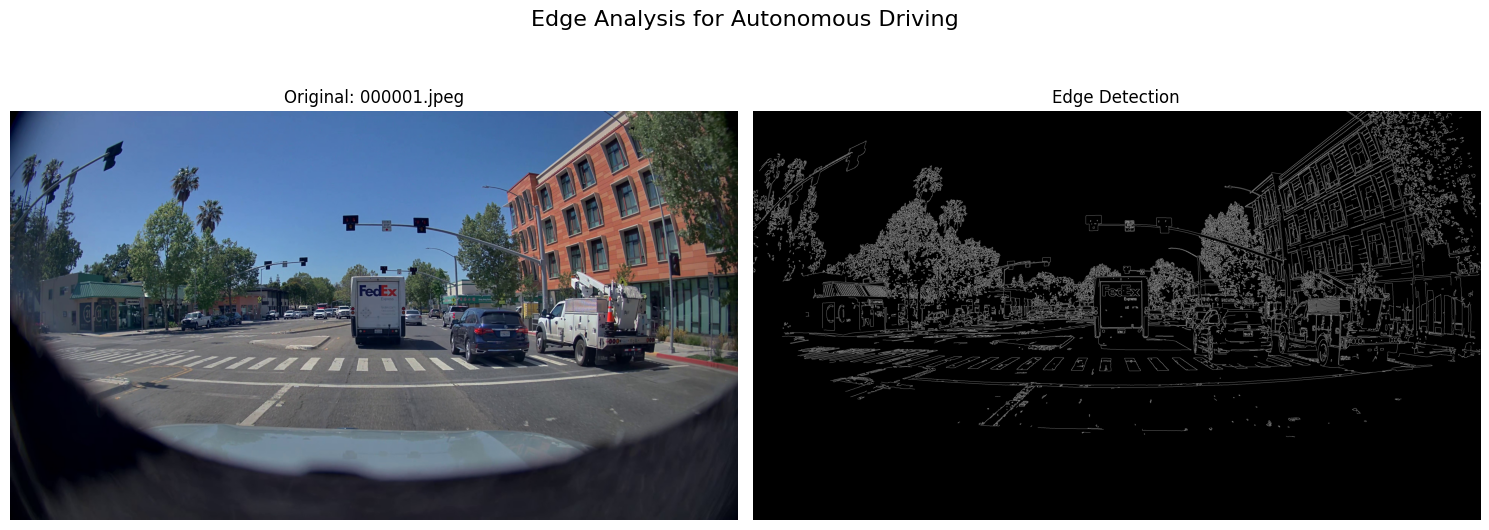


=== Displaying all evaluated images with scores ===


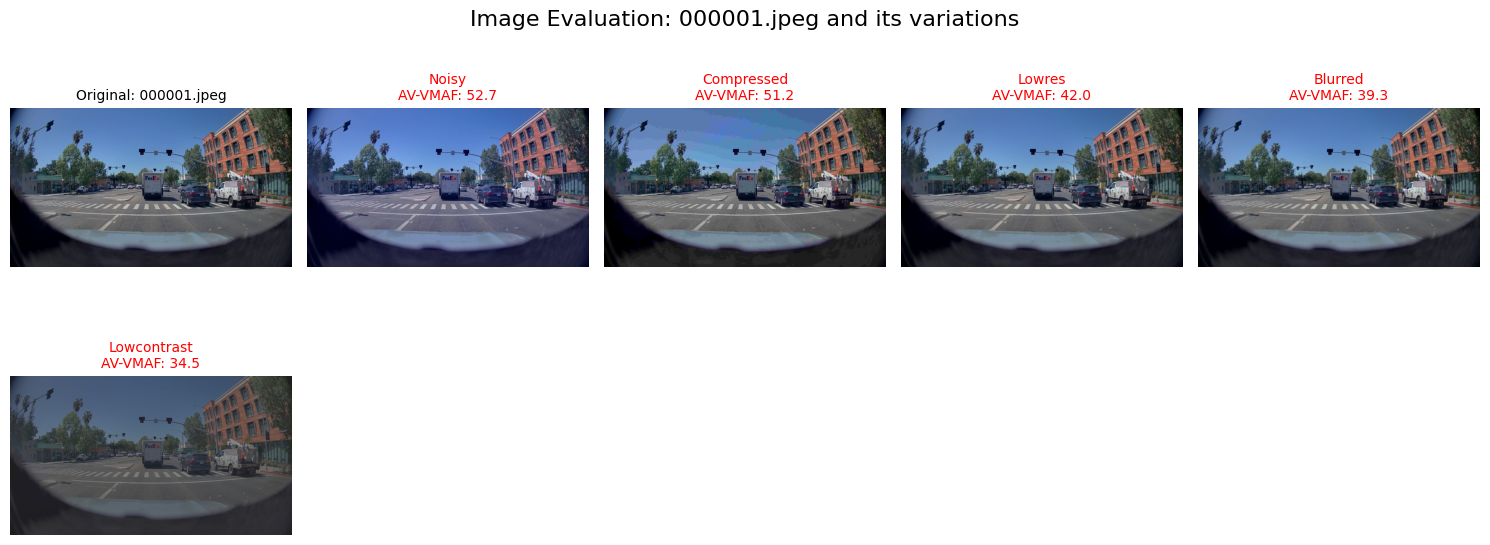


=== Edge detection comparison ===


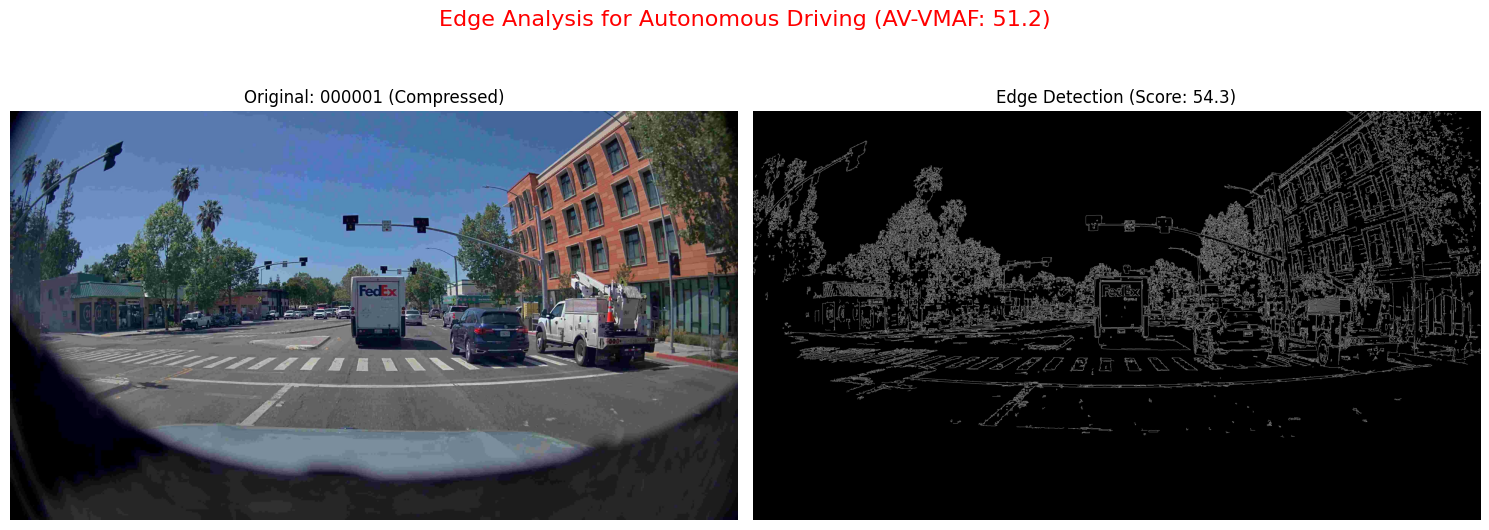

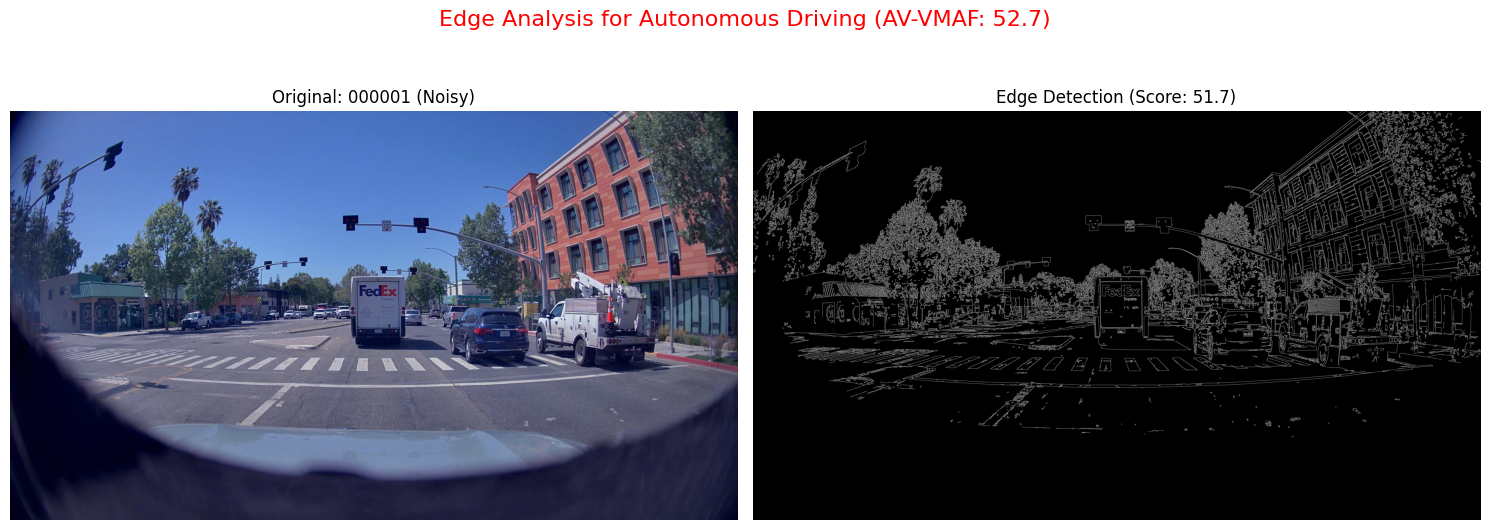

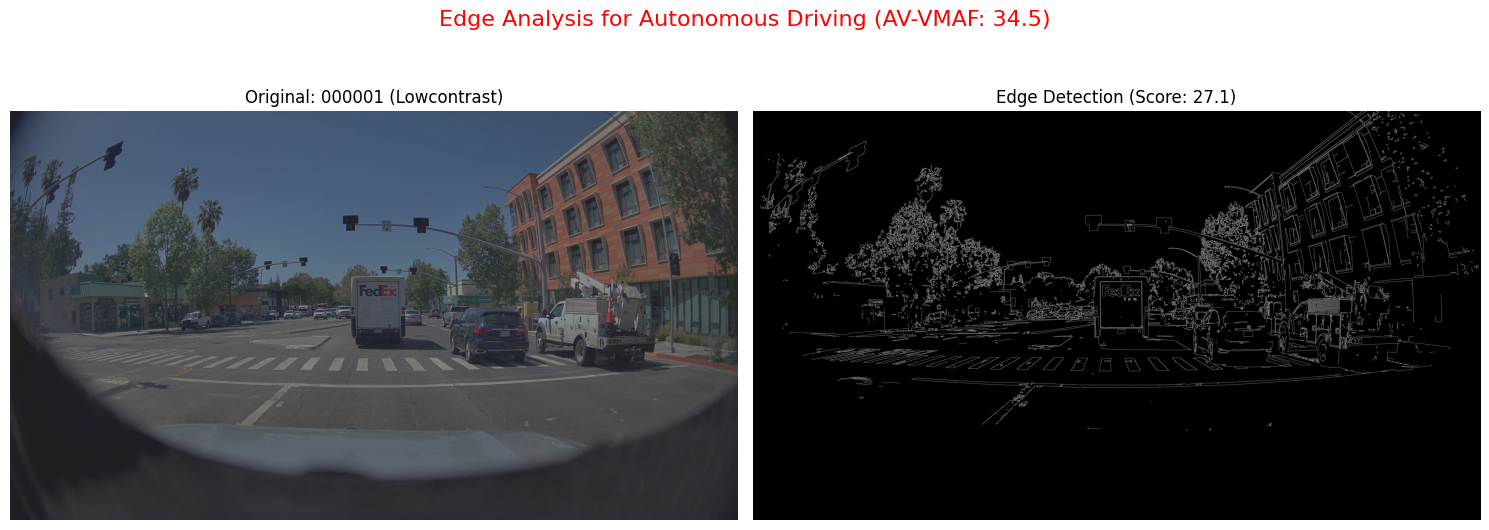

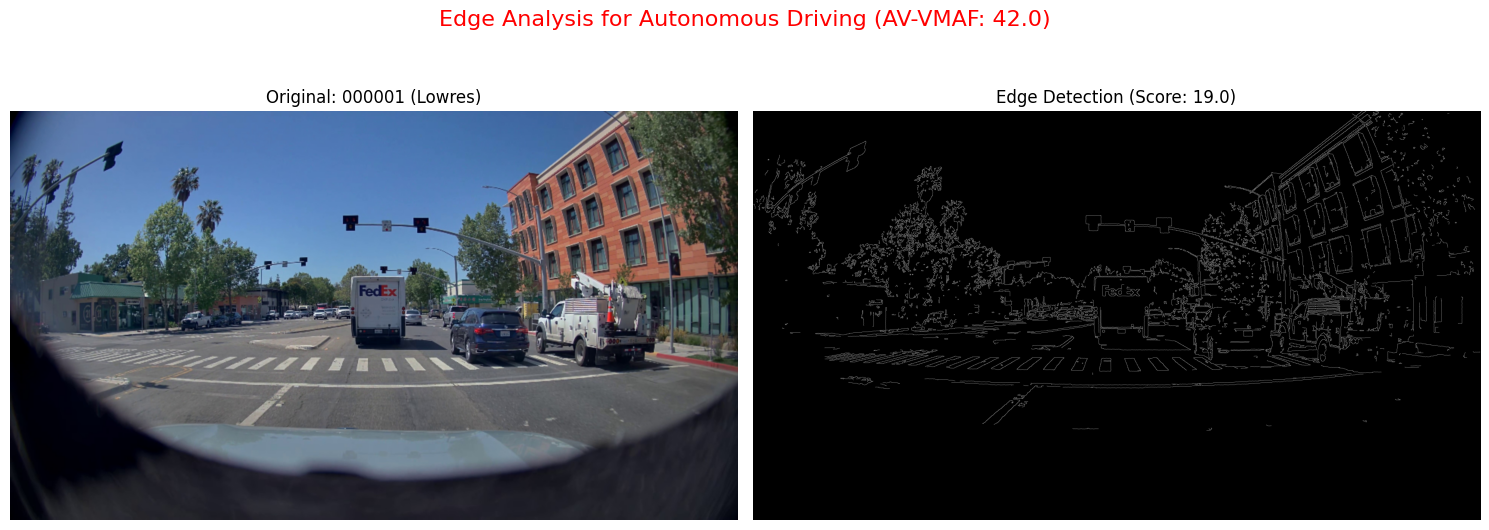

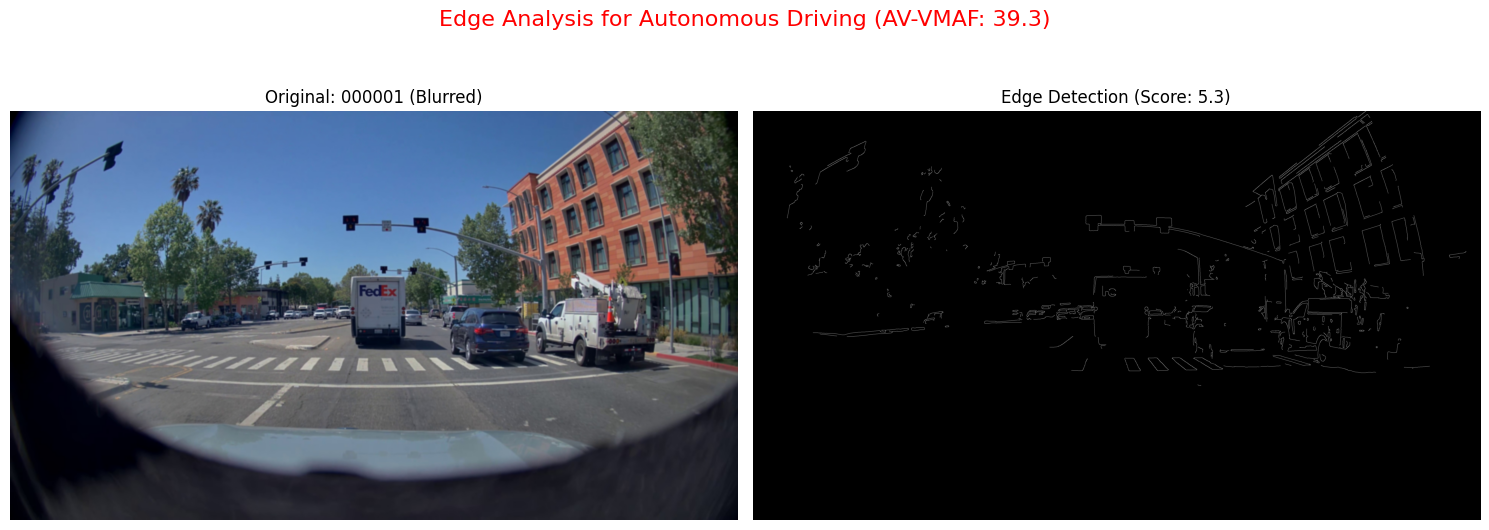


=== Metrics visualization ===


<ipython-input-3-242e224e1eb1>:436: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  chart = sns.barplot(x='filename', y='av_vmaf', data=results_df, palette='viridis')


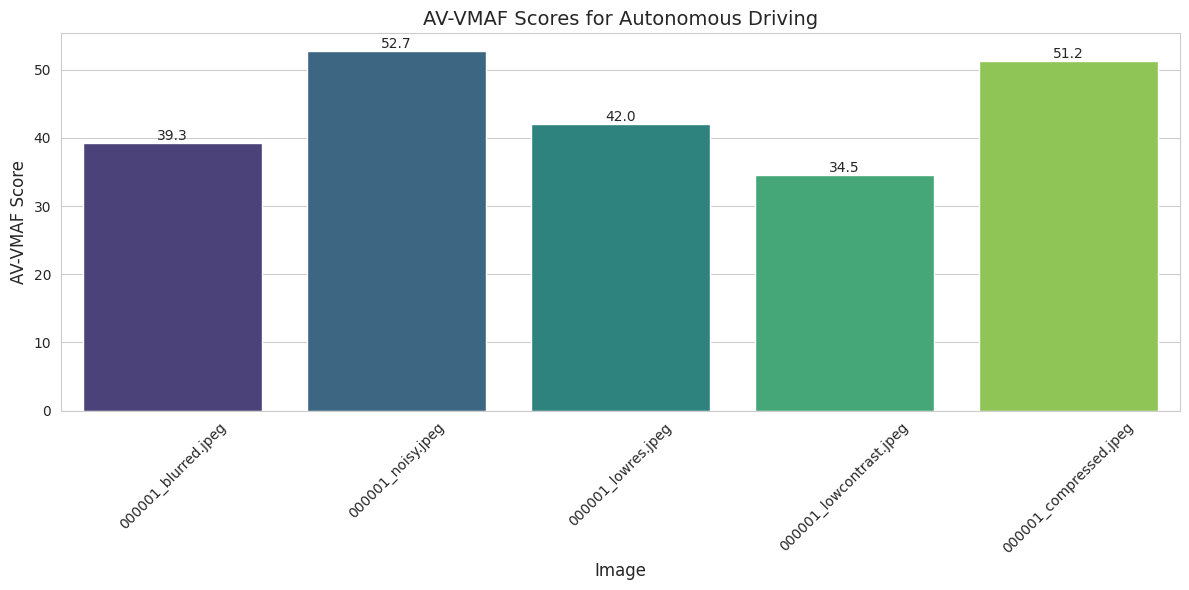

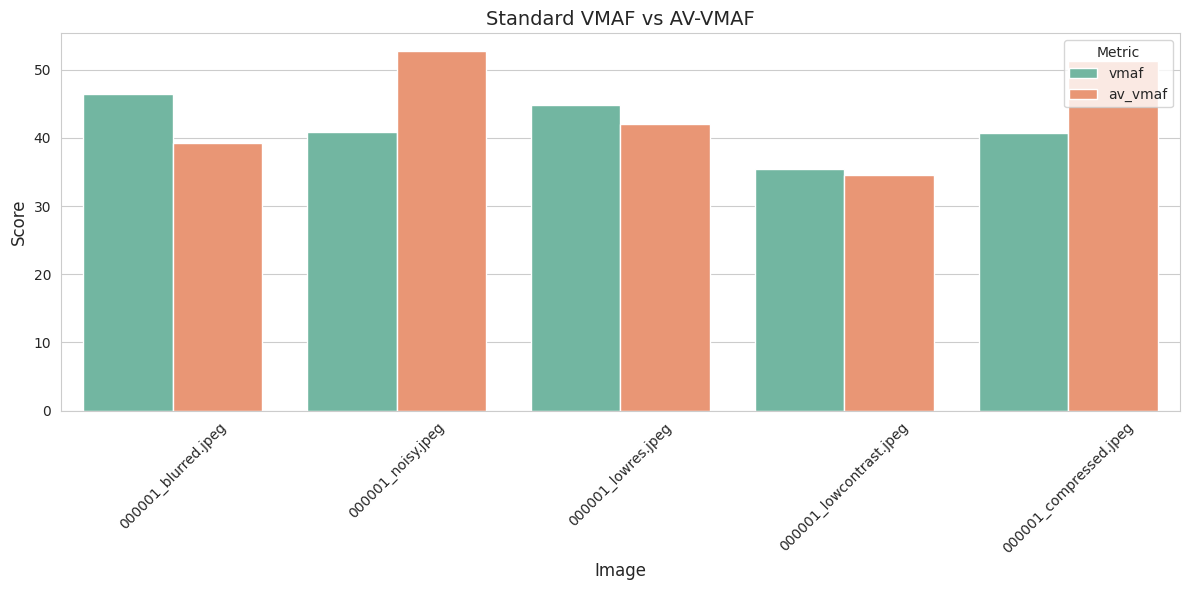

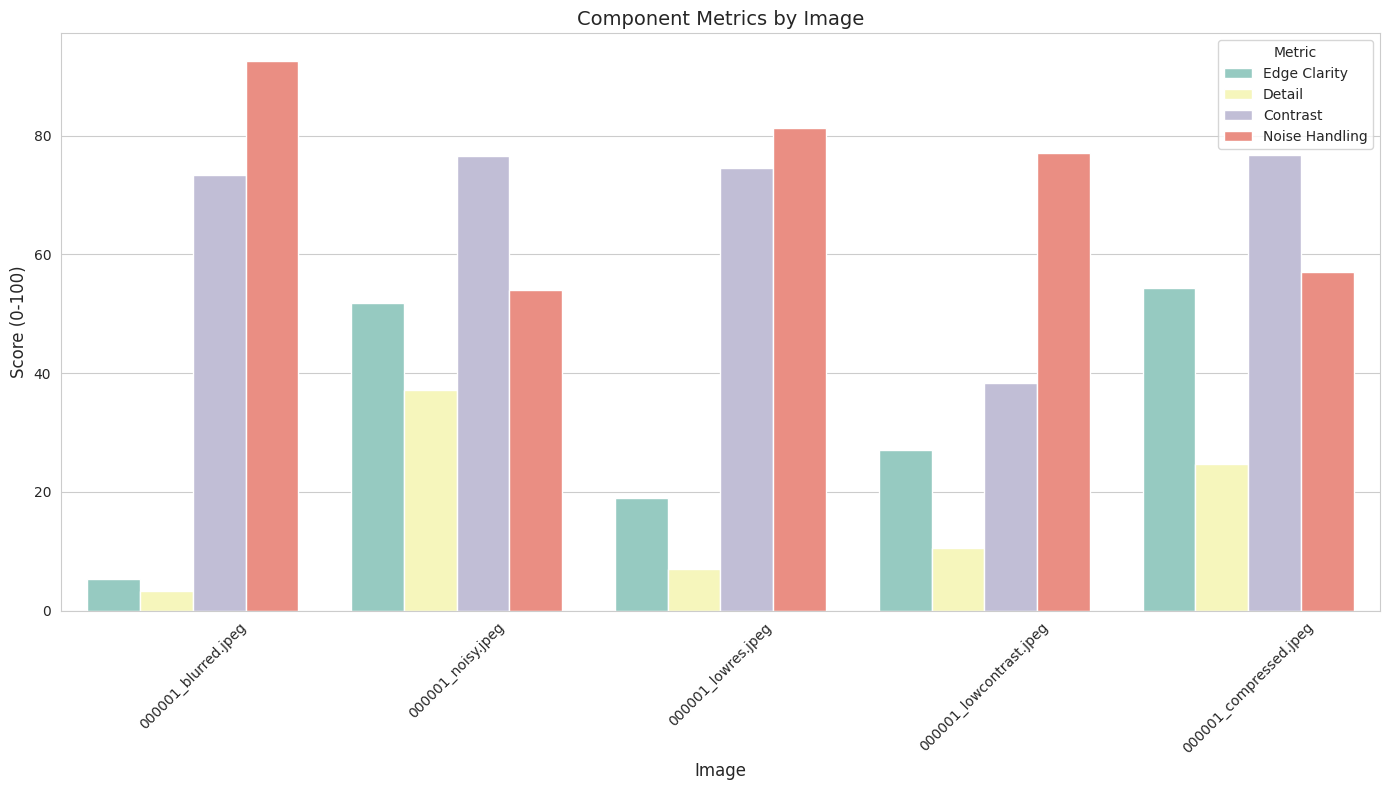

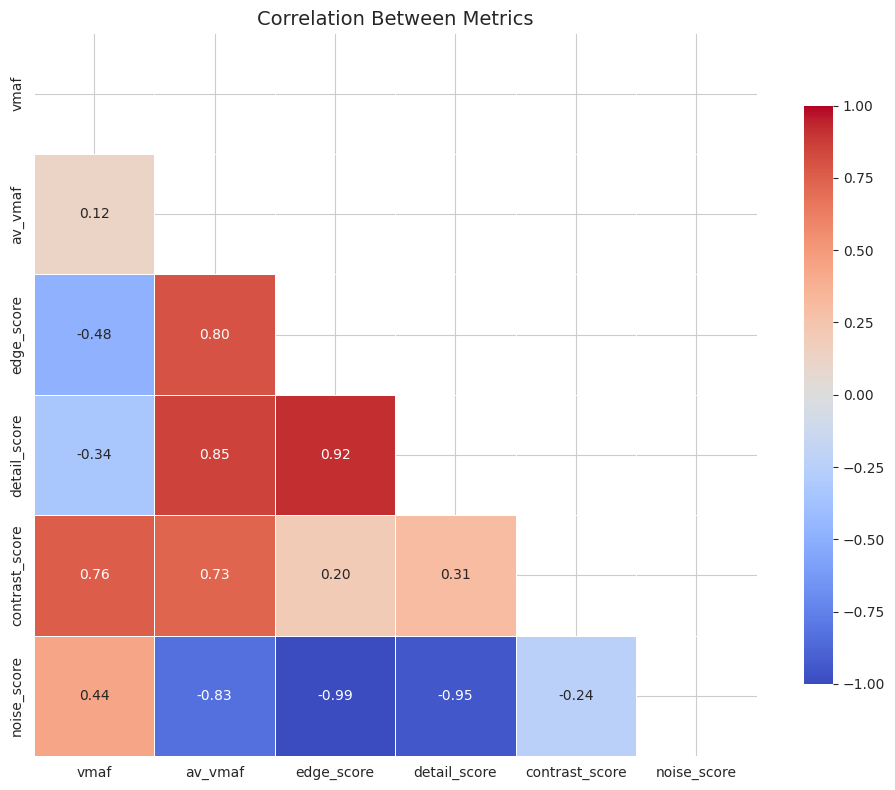

[{'filename': '000001_blurred.jpeg',
  'filepath': 'degraded_images/000001_blurred.jpeg',
  'vmaf': np.float64(46.465984341259194),
  'av_vmaf': np.float64(39.29890026181688),
  'edge_score': np.float64(5.319733796296297),
  'detail_score': np.float64(3.371726736268652),
  'contrast_score': np.float64(73.36810125777768),
  'noise_score': np.float64(92.57929095525115),
  'ref_filename': '000001.jpeg',
  'ref_filepath': 'reference_images/000001.jpeg',
  'degradation_type': 'Blur'},
 {'filename': '000001_noisy.jpeg',
  'filepath': 'degraded_images/000001_noisy.jpeg',
  'vmaf': np.float64(40.836903786269446),
  'av_vmaf': np.float64(52.7050102765729),
  'edge_score': np.float64(51.747202932098766),
  'detail_score': np.float64(37.18168436060881),
  'contrast_score': np.float64(76.47950795276444),
  'noise_score': np.float64(53.98746231047609),
  'ref_filename': '000001.jpeg',
  'ref_filepath': 'reference_images/000001.jpeg',
  'degradation_type': 'Noise'},
 {'filename': '000001_lowres.jpeg

In [4]:
upload_and_analyze()